Text(0.5, 1.0, 'PSD')

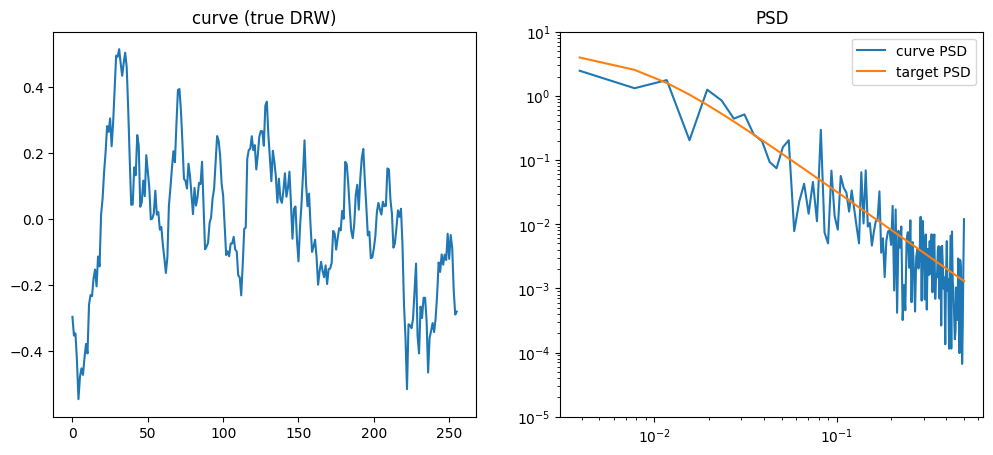

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))
ROOT_PATH = Path.cwd().parent.parent

import matplotlib.pyplot as plt
from src.amplitude_drw_curve_utils.utils import rayleigh_distribution, uniform_distribution, generate_curve, periodogram, red_noise_psd
from src.amplitude_drw_curve_utils.render_utils import render_amp_distribution_diagnostics, render_avg_psd_vs_target
from tqdm import tqdm
import numpy as np
import os

n = 256
decay = 0.95
tau = -1.0 / np.log(decay)
sigma_shape = 0.08

curve = generate_curve(
    n,
    distribution=rayleigh_distribution,
    decay=decay,
    sigma_shape=sigma_shape,
)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(curve)
plt.title("curve (true DRW)")
plt.subplot(1, 2, 2)
f, psd = periodogram(curve)
plt.loglog(f[1:], psd[1:], label="curve PSD")
plt.loglog(f[1:], red_noise_psd(f[1:], tau=tau, sigma_hat=sigma_shape), label="target PSD")
plt.legend()
plt.ylim(1e-5, 1e1)
plt.title("PSD")


### DRW dataset (true Rayleigh amplitude — reference/oracle)

In [2]:
dataset_size = 100_000
drw_curves = np.stack([
    generate_curve(
        n,
        distribution=rayleigh_distribution,
        decay=decay,
        sigma_shape=sigma_shape,
    )
    for _ in tqdm(range(dataset_size))
])
dataset_folder = "../../datasets/rayleigh_amplitude_drw"
os.makedirs(dataset_folder, exist_ok=True)
np.save(os.path.join(dataset_folder, "curves.npy"), drw_curves)


100%|██████████| 100000/100000 [00:05<00:00, 17054.35it/s]


In [3]:
dataset_size = 100_000
drw_curves_1024 = np.stack([
    generate_curve(
        1024,
        distribution=rayleigh_distribution,
        decay=decay,
        sigma_shape=sigma_shape,
    )
    for _ in tqdm(range(dataset_size))
])
dataset_folder = "../../datasets/auto_regressive_drw"
os.makedirs(dataset_folder, exist_ok=True)
np.save(os.path.join(dataset_folder, "curves.npy"), drw_curves_1024)


100%|██████████| 100000/100000 [00:08<00:00, 11551.93it/s]


Text(0.5, 1.0, 'PSD')

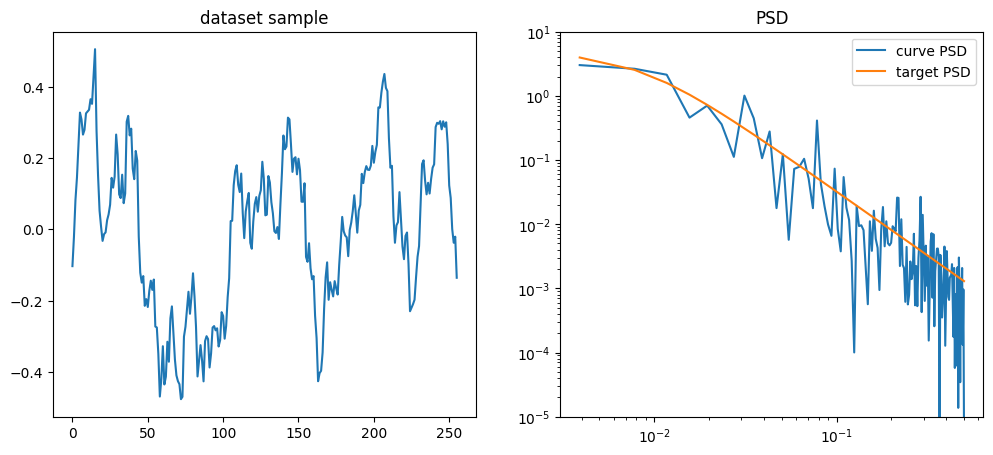

In [4]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(drw_curves[0])
plt.title("dataset sample")
plt.subplot(1, 2, 2)
f, psd = periodogram(drw_curves[0])
plt.loglog(f[1:], psd[1:], label="curve PSD")
plt.loglog(f[1:], red_noise_psd(f[1:], tau=tau, sigma_hat=sigma_shape), label="target PSD")
plt.legend()
plt.ylim(1e-5, 1e1)
plt.title("PSD")


In [5]:
sigma_shape

0.08

(<Figure size 1680x600 with 8 Axes>,
 {'avg_KS_vs_Uniform': 0.06991747362799866,
  'avg_KS_vs_Rayleigh': 0.0022182221697071777})

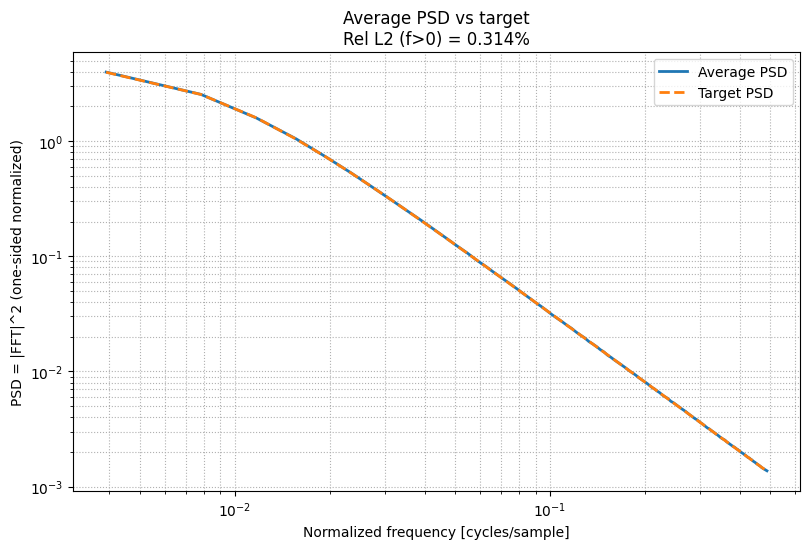

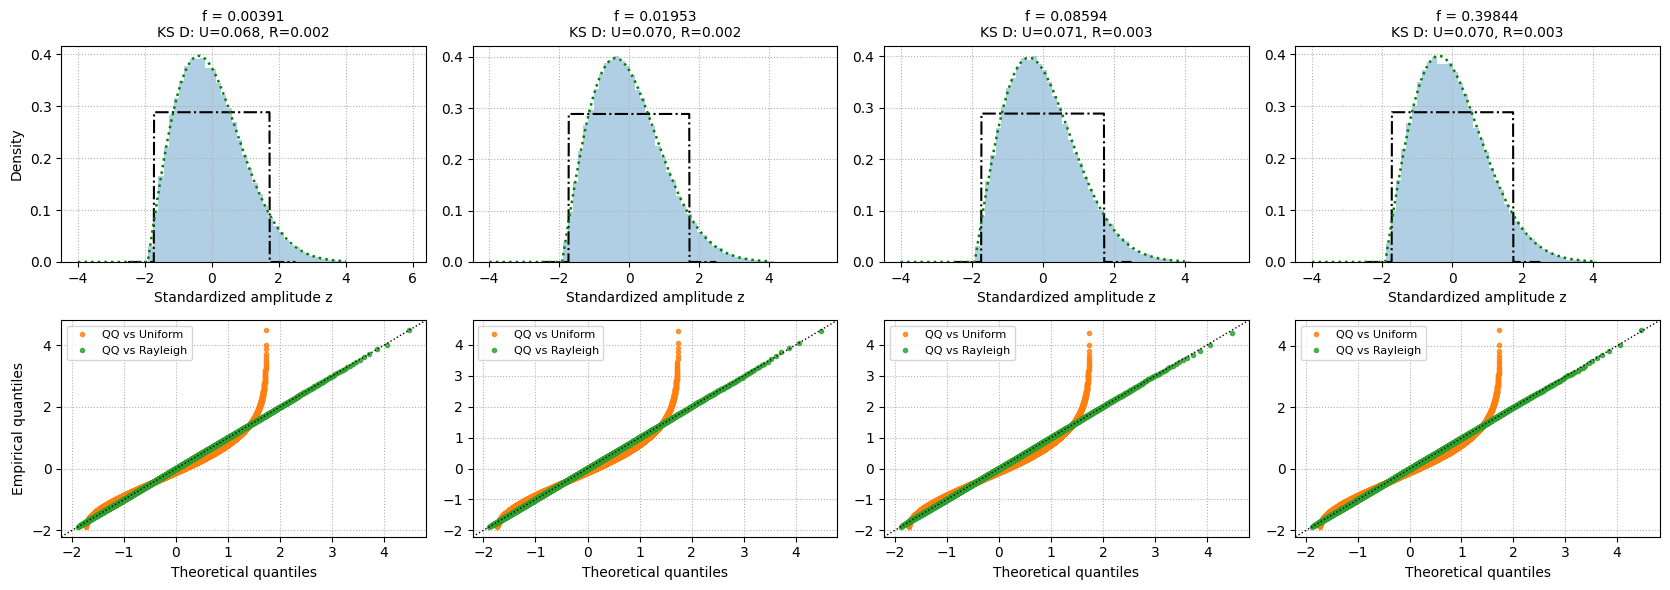

In [6]:
render_avg_psd_vs_target(drw_curves, tau=tau, sigma=sigma_shape)
render_amp_distribution_diagnostics(drw_curves)


### uniform dataset (ablation — same mean/variance as DRW, Uniform shape)

In [7]:
dataset_size = 100_000
uniform_curves = np.stack([
    generate_curve(
        n,
        distribution=uniform_distribution,
        decay=decay,
        sigma_shape=sigma_shape,
    )
    for _ in tqdm(range(dataset_size))
])
dataset_folder = "../../datasets/uniform_amplitude_drw"
os.makedirs(dataset_folder, exist_ok=True)
np.save(os.path.join(dataset_folder, "curves.npy"), uniform_curves)


100%|██████████| 100000/100000 [00:06<00:00, 16142.61it/s]


(<Figure size 1680x600 with 8 Axes>,
 {'avg_KS_vs_Uniform': 0.0020192205171287074,
  'avg_KS_vs_Rayleigh': 0.06965851795144196})

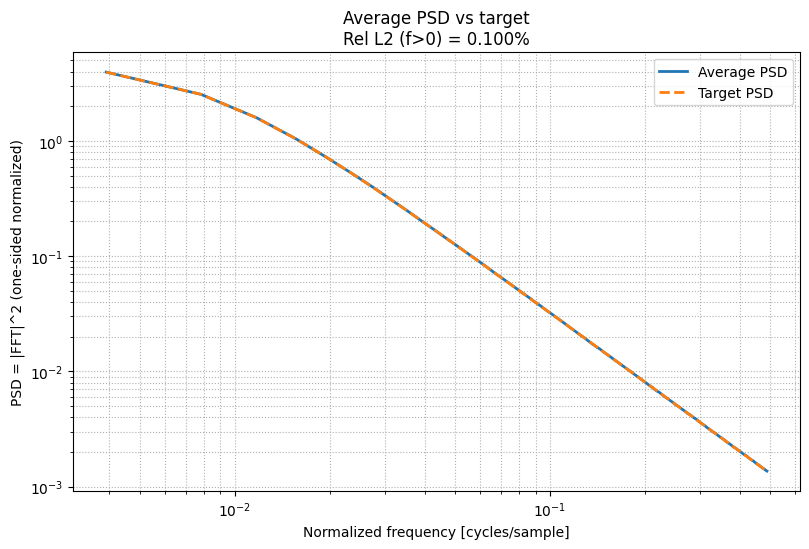

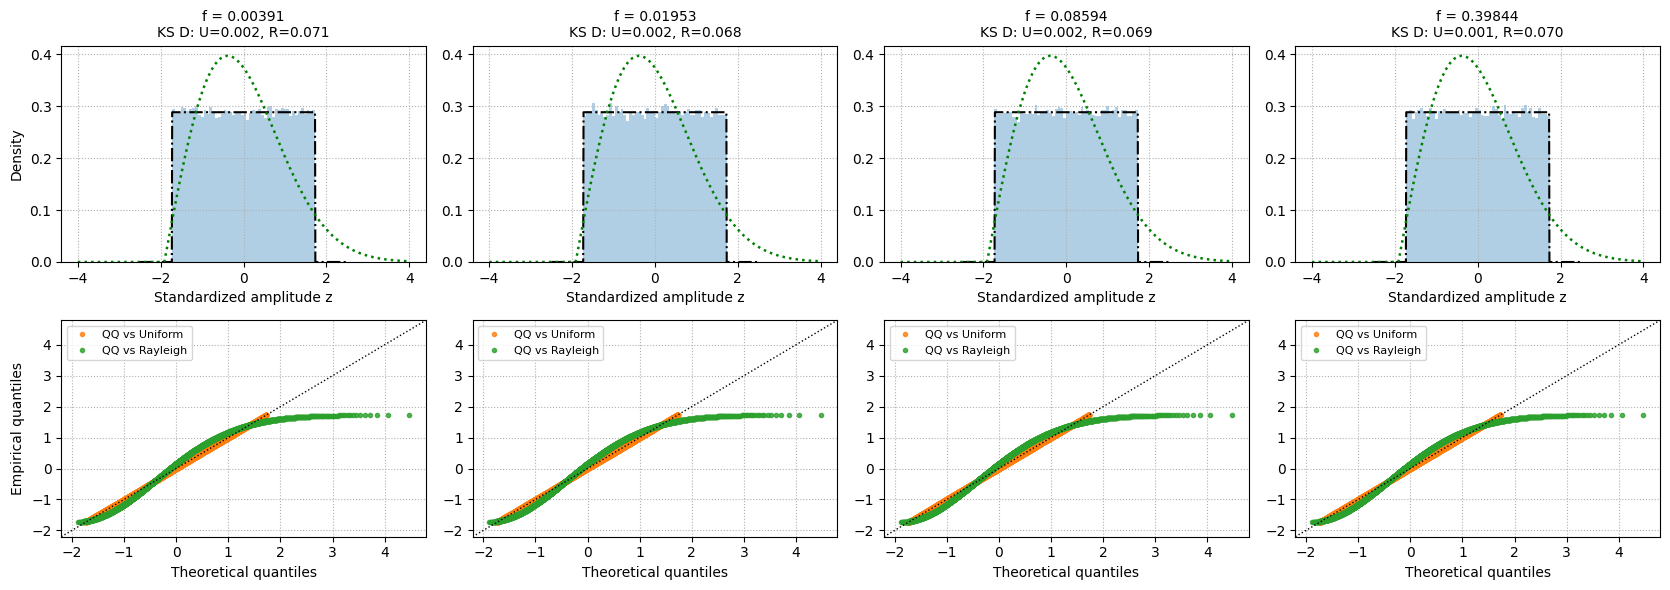

In [8]:
render_avg_psd_vs_target(uniform_curves, tau=tau, sigma=sigma_shape)
render_amp_distribution_diagnostics(uniform_curves)
